# Laboratory Exercise 1: Image Classification Using Pre-trained Models

## Comparative Benchmarking of Five Convolutional Neural Network Architectures for Fruit Freshness Classification

**Author:** Cristobal Tion  
**Course:** DS413 – Deep Learning  
**Laboratory Exercise:** 1  
**Focus:** Custom PyTorch Dataset Pipeline, Batched Evaluation, Transfer Learning, and Multi-Model Benchmarking  
**Dataset:** Custom Fruit Dataset – Fresh vs. Rotten  

### Overview

This laboratory exercise focuses on the implementation and evaluation of image classification models using a custom fruit dataset. The dataset consists of two classes: **Fresh** and **Rotten** fruits.

A custom PyTorch `Dataset` class and `DataLoader` objects are implemented to organize and process the image data efficiently. Five pre-trained convolutional neural network architectures from `torchvision.models` are then evaluated using transfer learning.

The models are compared using standard classification metrics, including **Accuracy, Precision, Recall, and F1-Score**. The results are presented through tables and visualizations to examine the differences in performance among the selected architectures.

### Dataset Classes

- **Class 0:** Fresh
- **Class 1:** Rotten

### Models Evaluated

1. ResNet-18
2. MobileNet-V2
3. EfficientNet-B0
4. DenseNet-121
5. VGG-16

The objective of this exercise is to demonstrate the complete image classification workflow, from dataset preparation and preprocessing to model evaluation, comparison, and interpretation of results.

## Fruit Freshness Classification

This laboratory exercise implements an image classification pipeline using a custom fruit dataset with two classes:

- **Class 0: Fresh**
- **Class 1: Rotten**

The workflow follows the structure demonstrated in the reference laboratory exercise:
1. Dataset curation and inspection
2. Custom PyTorch `Dataset`
3. Image transformations and `DataLoader`
4. Pre-trained ImageNet model inference
5. Transfer learning using five `torchvision.models` architectures
6. Evaluation using Accuracy, Precision, Recall, and F1-Score
7. Model comparison and visualization
8. Analysis and conclusion

> **Dataset folder structure**

```text
fruit_dataset/
├── fresh/
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ...
└── rotten/
    ├── image1.jpg
    ├── image2.jpg
    └── ...
```

In [1]:

# 1. Import required libraries

import os
import time
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("PyTorch version:", torch.__version__)


PyTorch version: 2.11.0+cpu


In [2]:

# Set device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu



## 1. Dataset Curation and Inspection

The dataset contains two classes: **Fresh** and **Rotten**.

The code below dynamically searches for the `fruit_dataset` folder and checks that both class folders are available.


In [19]:
import os
import pandas as pd

# Dataset location
dataset_root = "/content/fruit_dataset_extracted/fruit_dataset"

class_map = {
    0: "Fresh",
    1: "Rotten"
}

folder_to_label = {
    "fresh": 0,
    "rotten": 1
}

data_dict = {
    "X": [],
    "y": []
}

for folder_name, class_id in folder_to_label.items():

    class_folder = os.path.join(
        dataset_root,
        folder_name
    )

    for filename in sorted(os.listdir(class_folder)):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            filepath = os.path.join(
                class_folder,
                filename
            )

            data_dict["X"].append(filepath)
            data_dict["y"].append(class_id)


df_metadata = pd.DataFrame(data_dict)

df_metadata["Class_Name"] = df_metadata["y"].map(class_map)

print("Dataset root:", dataset_root)
print("Total images:", len(df_metadata))

print("\nClass distribution:")
print(df_metadata["Class_Name"].value_counts())

df_metadata.head()

Dataset root: /content/fruit_dataset_extracted/fruit_dataset
Total images: 10

Class distribution:
Class_Name
Fresh     5
Rotten    5
Name: count, dtype: int64


,X,y,Class_Name
0,/content/fruit_dataset_extracted/fruit_dataset...,0,Fresh
1,/content/fruit_dataset_extracted/fruit_dataset...,0,Fresh
2,/content/fruit_dataset_extracted/fruit_dataset...,0,Fresh
3,/content/fruit_dataset_extracted/fruit_dataset...,0,Fresh
4,/content/fruit_dataset_extracted/fruit_dataset...,0,Fresh


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


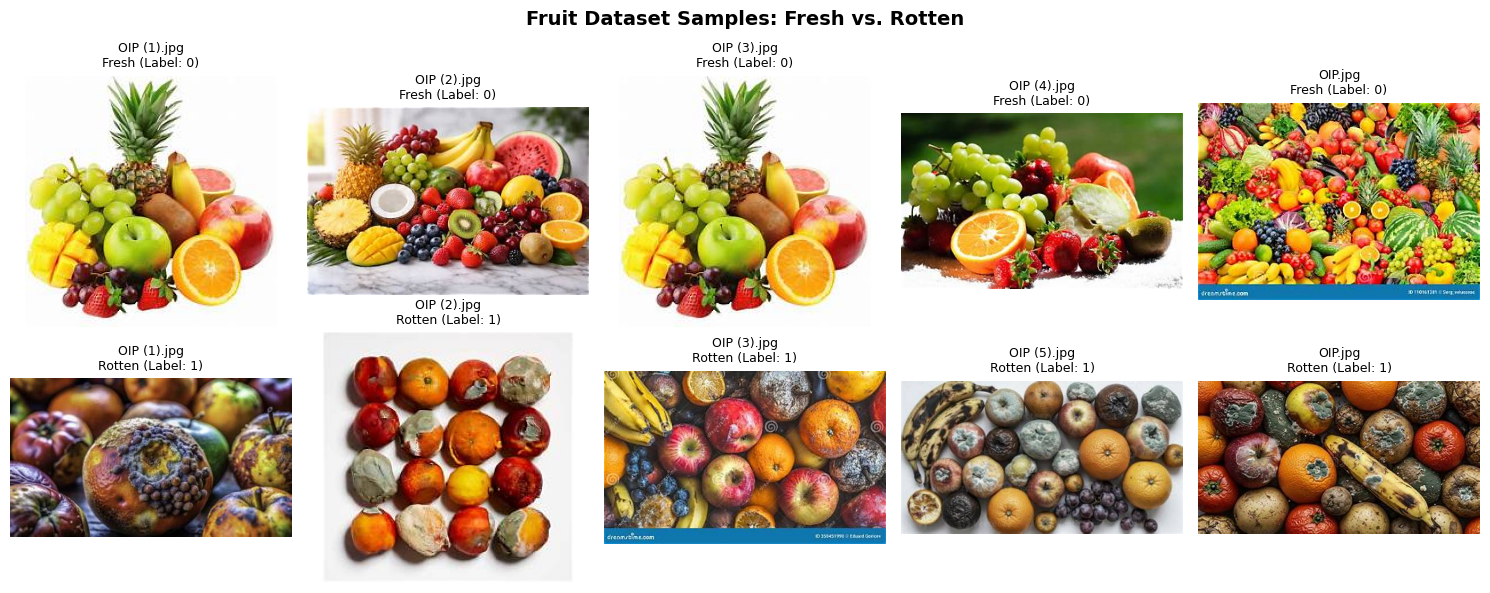

In [21]:
# Display sample images from both classes

sample_count = min(10, len(df_metadata))

sample_df = (
    pd.concat([
        df_metadata[df_metadata["y"] == 0].head(5),
        df_metadata[df_metadata["y"] == 1].head(5)
    ])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx, ax in enumerate(axes.flat):

    if idx >= len(sample_df):
        ax.axis("off")
        continue

    img_path = sample_df.loc[idx, "X"]
    cls_name = sample_df.loc[idx, "Class_Name"]
    cls_id = sample_df.loc[idx, "y"]

    bgr_img = cv2.imread(img_path)

    if bgr_img is not None:

        rgb_img = cv2.cvtColor(
            bgr_img,
            cv2.COLOR_BGR2RGB
        )

        ax.imshow(rgb_img)

    ax.set_title(
        f"{os.path.basename(img_path)}\n"
        f"{cls_name} (Label: {cls_id})",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Fruit Dataset Samples: Fresh vs. Rotten",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


## 2. Custom PyTorch Dataset Class

The custom `Dataset` class reads each image using OpenCV, converts the image from BGR to RGB, applies the defined transformations, and returns the image tensor together with its class label.


In [22]:

class CustomDataset(Dataset):
    def __init__(self, data_dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        img_path = self.data_dict["X"][idx]

        image = cv2.imread(img_path)

        if image is None:
            raise FileNotFoundError(
                f"Failed to load image at: {img_path}"
            )

        # OpenCV loads images as BGR.
        # Convert to RGB before applying torchvision transformations.
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = self.data_dict["y"][idx]

        if self.transforms is not None:
            image_rgb = self.transforms(image_rgb)

        target = torch.tensor(label, dtype=torch.long)

        return image_rgb, target

    def __len__(self):
        return len(self.data_dict["X"])



## 3. Image Transformations and DataLoader

The pretrained torchvision models use ImageNet-style preprocessing. Images are resized to `224 × 224`, converted to tensors, and normalized using ImageNet mean and standard deviation.


In [23]:

transform_pipeline = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

custom_dataset = CustomDataset(
    data_dict=data_dict,
    transforms=transform_pipeline
)

batch_size = 8

data_loader = DataLoader(
    custom_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Total samples:", len(custom_dataset))
print("Batch size:", batch_size)
print("Evaluation batches:", len(data_loader))

for batch_idx, (batch_images, batch_labels) in enumerate(data_loader):
    print(
        f"Batch {batch_idx + 1:02d}: "
        f"Images = {tuple(batch_images.shape)}, "
        f"Labels = {tuple(batch_labels.shape)}"
    )

    if batch_idx == 2:
        break


Total samples: 10
Batch size: 8
Evaluation batches: 2
Batch 01: Images = (8, 3, 224, 224), Labels = (8,)
Batch 02: Images = (2, 3, 224, 224), Labels = (2,)



## 4. Baseline Domain Shift: Raw ImageNet Inference

Before adapting the pretrained models to the two fruit classes, we can observe the predictions produced by a raw ImageNet model.

The raw ImageNet model predicts one of the 1,000 ImageNet categories. Therefore, its output is **not directly equivalent to Fresh or Rotten**. This demonstrates why transfer learning is useful when the target dataset has different classes from ImageNet.


In [24]:

weights_b0 = models.EfficientNet_B0_Weights.DEFAULT
model_b0_raw = models.efficientnet_b0(weights=weights_b0).to(device)
model_b0_raw.eval()

imagenet_categories = weights_b0.meta["categories"]

print(f"{'Image':<30} | {'True Class':<10} | {'ImageNet Prediction':<30} | Confidence")
print("-" * 95)

with torch.no_grad():
    for idx in range(min(len(custom_dataset), 10)):
        img_tensor, true_label = custom_dataset[idx]

        img_input = img_tensor.unsqueeze(0).to(device)

        logits = model_b0_raw(img_input)
        probabilities = F.softmax(logits, dim=1)

        pred_index = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0, pred_index].item()

        filename = os.path.basename(data_dict["X"][idx])
        truth_str = class_map[true_label.item()]
        predicted_category = imagenet_categories[pred_index]

        print(
            f"{filename:<30} | "
            f"{truth_str:<10} | "
            f"{predicted_category:<30} | "
            f"{confidence * 100:.2f}%"
        )


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 116MB/s] 


Image                          | True Class | ImageNet Prediction            | Confidence
-----------------------------------------------------------------------------------------------
OIP (1).jpg                    | Fresh      | Granny Smith                   | 15.12%
OIP (2).jpg                    | Fresh      | hamper                         | 61.50%
OIP (3).jpg                    | Fresh      | Granny Smith                   | 15.12%
OIP (4).jpg                    | Fresh      | strawberry                     | 17.39%
OIP.jpg                        | Fresh      | grocery store                  | 29.50%
OIP (1).jpg                    | Rotten     | custard apple                  | 15.32%
OIP (2).jpg                    | Rotten     | fig                            | 58.49%
OIP (3).jpg                    | Rotten     | banana                         | 24.91%
OIP (5).jpg                    | Rotten     | orange                         | 23.01%
OIP.jpg                        | Rotten 


## 5. Multi-Model Transfer Learning

Five pretrained architectures are adapted for binary classification:

1. **ResNet-18**
2. **MobileNet-V2**
3. **EfficientNet-B0**
4. **DenseNet-121**
5. **VGG-16**

The pretrained feature extraction layers are frozen, while the final classification layer is replaced with a two-class output layer for **Fresh** and **Rotten**.


In [25]:

def initialize_model(model_name, num_classes=2):

    if model_name == "ResNet-18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "MobileNet-V2":
        weights = models.MobileNet_V2_Weights.DEFAULT
        model = models.mobilenet_v2(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "EfficientNet-B0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "DenseNet-121":
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    elif model_name == "VGG-16":
        weights = models.VGG16_Weights.DEFAULT
        model = models.vgg16(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(device)



## 6. Model Training and Benchmarking

Each model trains only its newly replaced classification head. The same evaluation dataset is used to calculate Accuracy, Precision, Recall, F1-Score, confusion matrices, and inference latency.

> **Note:** This follows the structure of the provided reference notebook. For a stricter machine-learning experiment, a separate train/validation/test split should be used so that the evaluation images are not the same images used during training.


In [26]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


model_candidates = [
    "ResNet-18",
    "MobileNet-V2",
    "EfficientNet-B0",
    "DenseNet-121",
    "VGG-16"
]

benchmark_records = []
stored_confusion_matrices = {}
stored_predictions = {}
stored_probabilities = {}

train_loader = DataLoader(
    custom_dataset,
    batch_size=batch_size,
    shuffle=True
)

for name in model_candidates:

    print(f"\nTraining and evaluating {name}...")
    set_seed(42)

    model = initialize_model(name, num_classes=2)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.005
    )

    # Train the classification head
    model.train()

    for epoch in range(15):

        running_loss = 0.0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

    # Evaluation
    model.eval()

    ground_truth = []
    model_predictions = []
    class_probabilities = []

    start_time = time.time()

    with torch.no_grad():

        for inputs, targets in data_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            probs = F.softmax(outputs, dim=1)
            predictions = torch.argmax(probs, dim=1)

            ground_truth.extend(targets.cpu().numpy())
            model_predictions.extend(predictions.cpu().numpy())
            class_probabilities.extend(
                probs[:, 1].cpu().numpy()
            )

    latency_ms = (time.time() - start_time) * 1000

    accuracy = accuracy_score(
        ground_truth,
        model_predictions
    )

    precision = precision_score(
        ground_truth,
        model_predictions,
        average="binary",
        zero_division=0
    )

    recall = recall_score(
        ground_truth,
        model_predictions,
        average="binary",
        zero_division=0
    )

    f1 = f1_score(
        ground_truth,
        model_predictions,
        average="binary",
        zero_division=0
    )

    cm = confusion_matrix(
        ground_truth,
        model_predictions,
        labels=[0, 1]
    )

    total_parameters = sum(
        p.numel() for p in model.parameters()
    )

    trainable_parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    benchmark_records.append({
        "Model Architecture": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Latency (ms)": latency_ms,
        "Total Parameters": total_parameters,
        "Trainable Parameters": trainable_parameters
    })

    stored_confusion_matrices[name] = cm
    stored_predictions[name] = model_predictions
    stored_probabilities[name] = class_probabilities

    print(
        f"Accuracy: {accuracy:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )



Training and evaluating ResNet-18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 91.8MB/s]


Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000

Training and evaluating MobileNet-V2...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 64.5MB/s]


Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000

Training and evaluating EfficientNet-B0...
Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000

Training and evaluating DenseNet-121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 152MB/s]


Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000

Training and evaluating VGG-16...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 91.7MB/s]


Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000



## 7. Comparative Results


In [27]:

df_results = pd.DataFrame(benchmark_records)

df_table_view = df_results.copy()

df_table_view["Accuracy"] = df_table_view["Accuracy"].round(4)
df_table_view["Precision"] = df_table_view["Precision"].round(4)
df_table_view["Recall"] = df_table_view["Recall"].round(4)
df_table_view["F1-Score"] = df_table_view["F1-Score"].round(4)
df_table_view["Latency (ms)"] = df_table_view["Latency (ms)"].round(2)

print("=== FRUIT FRESHNESS MODEL COMPARISON ===")

display(df_table_view)


=== FRUIT FRESHNESS MODEL COMPARISON ===


,Model Architecture,Accuracy,Precision,Recall,F1-Score,Latency (ms),Total Parameters,Trainable Parameters
0,ResNet-18,1.0,1.0,1.0,1.0,1203.89,11177538,1026
1,MobileNet-V2,1.0,1.0,1.0,1.0,372.87,2226434,2562
2,EfficientNet-B0,1.0,1.0,1.0,1.0,497.18,4010110,2562
3,DenseNet-121,1.0,1.0,1.0,1.0,1436.82,6955906,2050
4,VGG-16,1.0,1.0,1.0,1.0,6938.32,134268738,8194


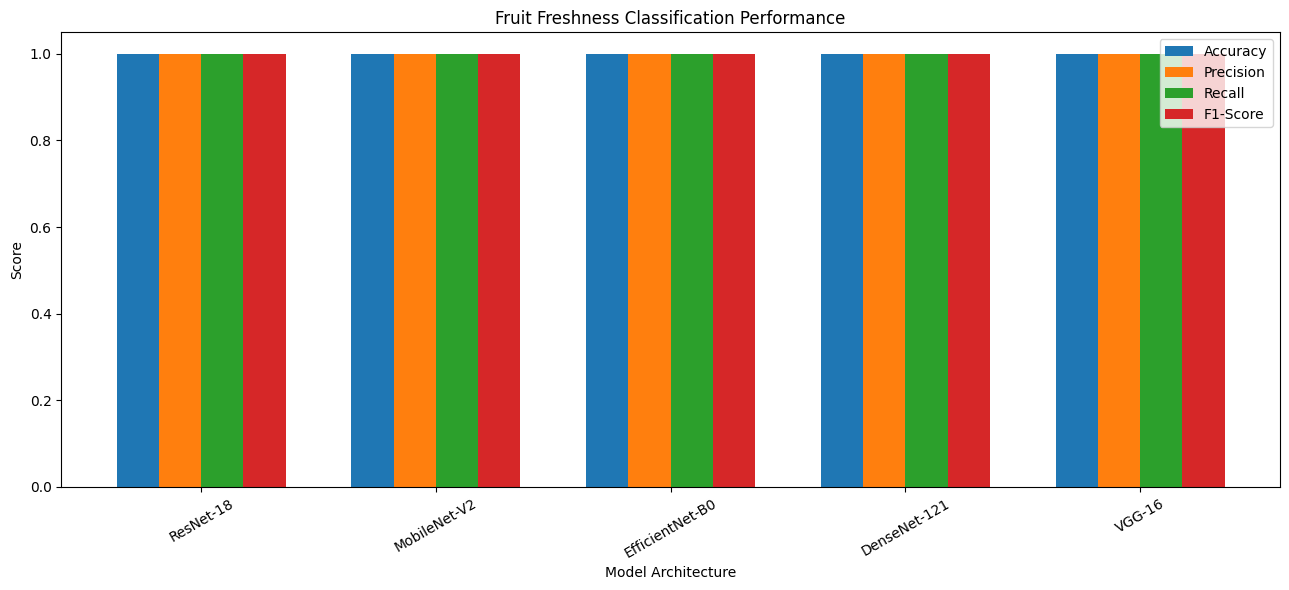

In [28]:

# Performance comparison visualization

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(len(df_results))
width = 0.18

plt.figure(figsize=(13, 6))

for i, metric in enumerate(metric_names):
    plt.bar(
        x + (i - 1.5) * width,
        df_results[metric],
        width,
        label=metric
    )

plt.title("Fruit Freshness Classification Performance")
plt.xlabel("Model Architecture")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(x, df_results["Model Architecture"], rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


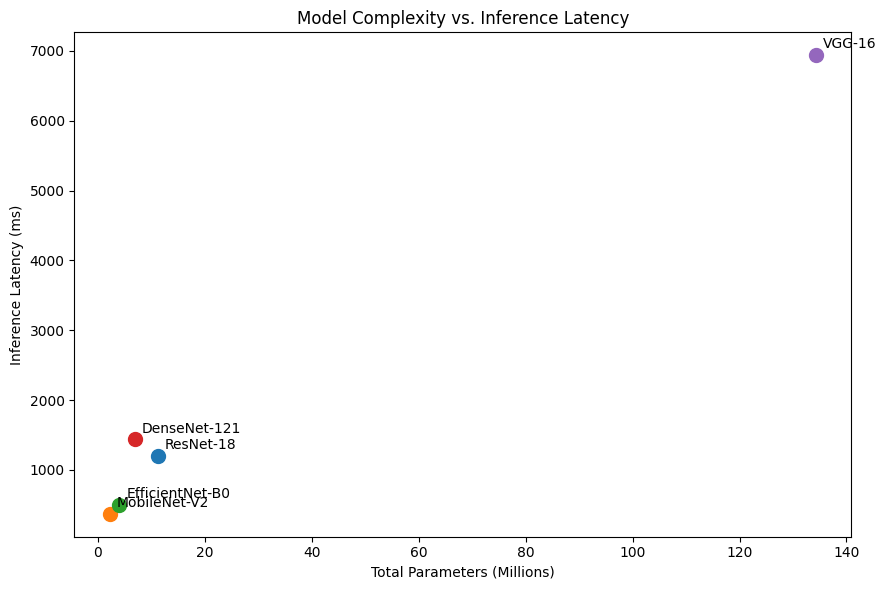

In [29]:

# Parameter count vs. inference latency

plt.figure(figsize=(9, 6))

for _, row in df_results.iterrows():
    plt.scatter(
        row["Total Parameters"] / 1e6,
        row["Latency (ms)"],
        s=100
    )

    plt.annotate(
        row["Model Architecture"],
        (
            row["Total Parameters"] / 1e6,
            row["Latency (ms)"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total Parameters (Millions)")
plt.ylabel("Inference Latency (ms)")
plt.title("Model Complexity vs. Inference Latency")
plt.tight_layout()
plt.show()


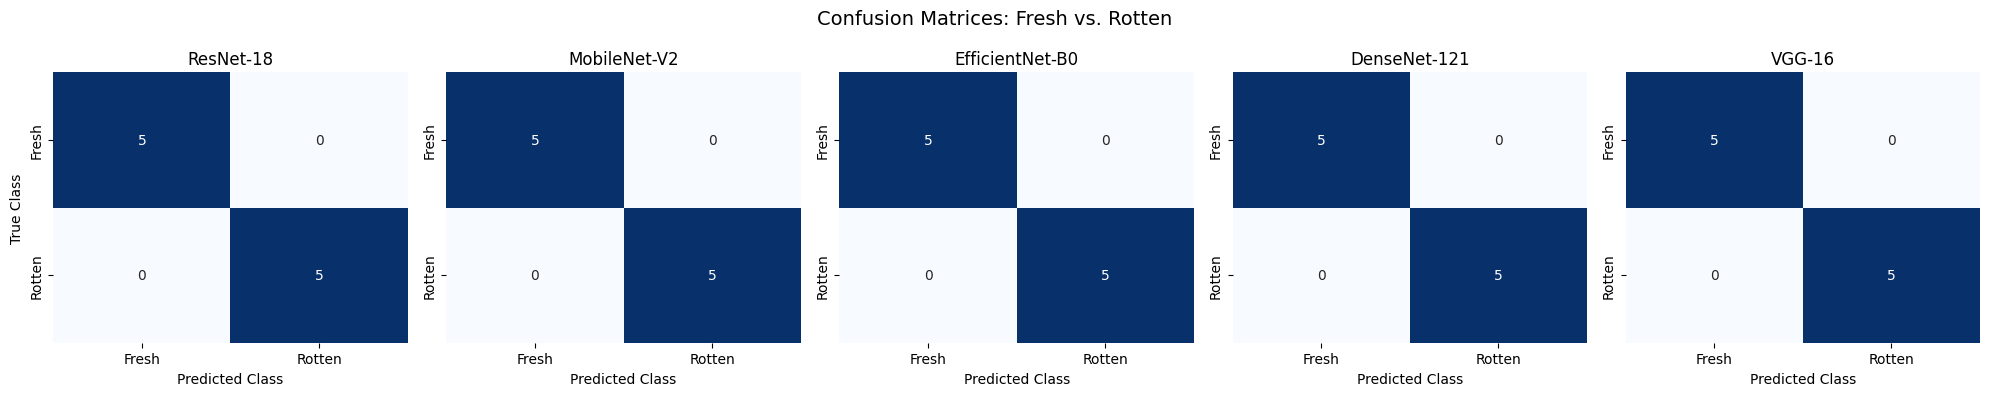

In [30]:

# Confusion matrices

fig, axes = plt.subplots(
    1,
    len(model_candidates),
    figsize=(20, 4)
)

for idx, name in enumerate(model_candidates):

    cm = stored_confusion_matrices[name]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Fresh", "Rotten"],
        yticklabels=["Fresh", "Rotten"],
        ax=axes[idx]
    )

    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted Class")

    if idx == 0:
        axes[idx].set_ylabel("True Class")
    else:
        axes[idx].set_ylabel("")

plt.suptitle(
    "Confusion Matrices: Fresh vs. Rotten",
    fontsize=14
)

plt.tight_layout()
plt.show()


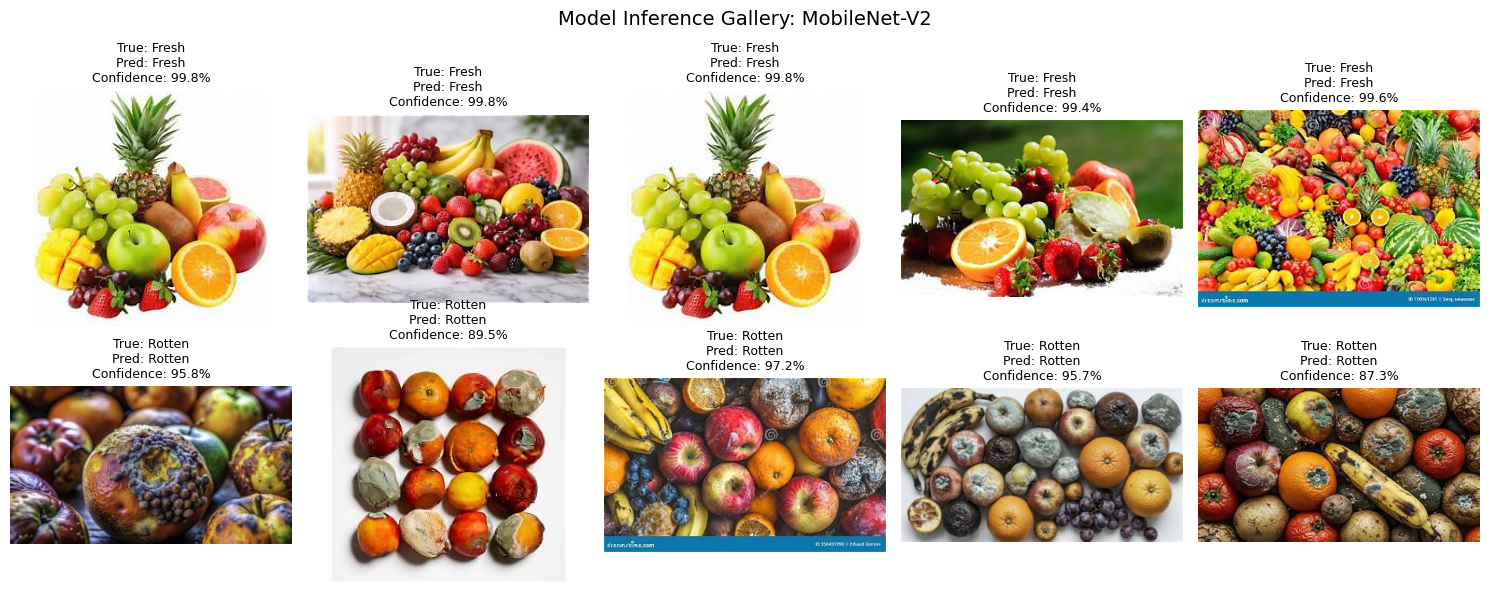

In [31]:

# Inference gallery using the first evaluated model

eval_model = "MobileNet-V2"

preds = stored_predictions[eval_model]
probs = stored_probabilities[eval_model]

gallery_count = min(10, len(custom_dataset))

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for idx, ax in enumerate(axes.flat):

    if idx >= gallery_count:
        ax.axis("off")
        continue

    img_path = df_metadata["X"].iloc[idx]
    true_cls = df_metadata["y"].iloc[idx]
    pred_cls = preds[idx]

    confidence = (
        probs[idx]
        if pred_cls == 1
        else 1 - probs[idx]
    )

    raw_img = cv2.imread(img_path)
    rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    ax.imshow(rgb_img)

    ax.set_title(
        f"True: {class_map[true_cls]}\n"
        f"Pred: {class_map[pred_cls]}\n"
        f"Confidence: {confidence * 100:.1f}%",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    f"Model Inference Gallery: {eval_model}",
    fontsize=14
)

plt.tight_layout()
plt.show()



## 8. Classification Report

The classification report provides class-level precision, recall, and F1-score for the selected model.


In [32]:

selected_model = "MobileNet-V2"

print(
    classification_report(
        df_metadata["y"],
        stored_predictions[selected_model],
        target_names=["Fresh", "Rotten"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00         5
      Rotten       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




## 9. Analysis and Discussion

The five pretrained architectures may produce different results because they use different network designs and have different levels of model complexity.

**ResNet-18** uses residual connections that allow information to pass through shortcut connections. This can help the network extract useful visual features while keeping the architecture relatively lightweight.

**MobileNet-V2** uses depthwise separable convolutions and inverted residual blocks. It is designed to reduce the number of computations and parameters, which can make it useful for systems with limited computational resources.

**EfficientNet-B0** uses compound scaling to balance network depth, width, and image resolution. This allows it to obtain useful feature representations while keeping the model relatively compact.

**DenseNet-121** uses dense connections between layers. These connections encourage feature reuse and can help the model preserve useful visual information.

**VGG-16** uses a traditional convolutional architecture with many parameters, especially in its fully connected layers. Its larger parameter count can increase computational requirements.

The results are also affected by the characteristics of the fruit dataset. Factors such as lighting, background, camera angle, fruit type, image quality, amount of training data, and the visual difference between fresh and rotten fruit can influence classification performance.

Accuracy describes the overall percentage of correct predictions. Precision describes how often predictions for the positive class are correct, while recall measures how many actual positive samples were detected. F1-score provides a balance between precision and recall.

The numerical results in the table above should be used when writing the final comparison. Avoid claiming that one model is better unless the actual measured metrics support that observation.



## 10. Conclusion

In this laboratory exercise, a custom fruit dataset containing **Fresh** and **Rotten** classes was used to implement an image classification workflow in PyTorch. A custom `Dataset` class was created to load and transform the images, and a `DataLoader` was used to process the images in batches.

Five pretrained architectures from `torchvision.models`—**ResNet-18, MobileNet-V2, EfficientNet-B0, DenseNet-121, and VGG-16**—were adapted using transfer learning for binary fruit freshness classification.

The models were compared using **Accuracy, Precision, Recall, and F1-Score**, together with inference latency and parameter counts. The results demonstrate that pretrained models can provide useful visual features for a new classification problem, but their performance can vary depending on the model architecture, complexity, and characteristics of the dataset.

For the final portfolio entry, the numerical results and visualizations generated by this notebook should be discussed to explain the observed differences between the five models.
